# Build a Leakage-Safe ML Pipeline: The Honest Way to Evaluate Models

**Data leakage** is when information from the rows you will be judged on sneaks
into any step of your pipeline that *learns from data*. One sentence -- that is
the whole disease. The symptom: offline metrics look great, production looks
nothing like them.

This notebook demonstrates the crime, measures its cost, and shows the cure,
using [dextra](https://pypi.org/project/pydextra/) -- a data-analysis toolkit
built on one rule: **every automatic decision is disclosed, and you stay in
charge.** Its FIT -> APPLY contract (fit parameters on training data, replay
them verbatim anywhere else) is the safeguard this whole notebook leans on.

Three layers, two real datasets:

1. **Layer 1 -- the subtle crime** (Telco churn): impute + encode + scale on
   all rows before splitting. Measurable? Barely. We will say so honestly.
2. **Layer 2 -- the invisible crime** (KDD Cup 09 churn): select features
   while the test rows are watching. On wide, weak-signal data the bias is
   real -- and a single train/test check cannot even see it.
3. **Layer 3 -- proof by repetition**: 20 random splits, then repeated
   cross-validation. Averaging shrinks the noise; the bias survives it.
   That asymmetry is the whole case against leakage.

Finale: a fully honest evaluation of the model we actually trust --
cross-validated baseline, confusion diagnostics, ROC/PR, learning curves --
all leak-free.

## The two datasets

**Telco Customer Churn** (IBM sample dataset). 7,043 customers x 21 columns;
binary target `Churn`. One numeric column (`TotalCharges`) hides blanks; a
handful of Yes/No columns. Tame and low-dimensional -- the perfect place to
show that the subtle crime barely registers.

**KDD Cup 2009 -- Orange churn** ([OpenML data_id=1112](https://www.openml.org/d/1112),
license: Public). 50,000 rows x 230 anonymized
features (192 of which arrive numeric through `fetch_openml`), target `CHURN`
in {-1, 1}, missingness everywhere. We will take
a small, documented sample to recreate the many-features/few-rows regime where
selection leakage explodes.

Why two datasets? Because honesty requires both: the case where the crime is
nearly free, and the case where it costs you the project.

In [1]:
%pip install -q "pydextra[io,ml]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: D:\06 PythonProjects\dextra-project\notebooks\.venv-nb\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import sklearn
import dextra as dx

print("dextra", dx.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__)

dextra 0.6.0 | pandas 3.0.3 | scikit-learn 1.9.0


## Part 1 -- Telco: load it honestly

The next cell downloads the Telco CSV once (~1 MB) from IBM's public GitHub
repository and caches it in `data/`; re-runs use the cached copy.

In [3]:
import urllib.request
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
TELCO_URL = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
             "master/data/Telco-Customer-Churn.csv")
TELCO_PATH = DATA_DIR / "Telco-Customer-Churn.csv"
if not TELCO_PATH.exists():
    urllib.request.urlretrieve(TELCO_URL, TELCO_PATH)
print(f"cached: {TELCO_PATH} ({TELCO_PATH.stat().st_size / 1e6:.2f} MB)")

cached: data\Telco-Customer-Churn.csv (0.97 MB)


In [4]:
df = dx.load(str(TELCO_PATH))

source=Telco-Customer-Churn.csv | encoding=utf-8 | sep=',' | header=row 0 | 7,043x21
          column   dtype  parsed_%  null_%  n_distinct problem   action confidence
      customerID  object  100.0000  0.0000        7043                   confirmed
          gender  object  100.0000  0.0000           2         category  confirmed
   SeniorCitizen   int64  100.0000  0.0000           2                   confirmed
         Partner boolean  100.0000  0.0000           2                   confirmed
      Dependents boolean  100.0000  0.0000           2                   confirmed
          tenure   int64  100.0000  0.0000          73                   confirmed
    PhoneService boolean  100.0000  0.0000           2                   confirmed
   MultipleLines  object  100.0000  0.0000           3         category  confirmed
 InternetService  object  100.0000  0.0000           3         category  confirmed
  OnlineSecurity  object  100.0000  0.0000           3         category  confirmed
  

### Read the report before touching anything

Two disclosures in the load report matter here:

- **`TotalCharges` arrived as text.** The column is ~99.8% parseable numbers
  plus a handful of literal blanks; `load` coerced it to float64 and the
  report row discloses the outcome: `null_% = 0.16` -- 11 cells out of 7,043,
  parsed as missing. Those blanks are brand-new customers (tenure 0) whose
  first bill has not landed yet -- real missingness with a real business
  meaning, and our first candidate for *fitted* imputation.
- **Five Yes/No columns became `boolean`** (including the target `Churn`).
  No hidden magic: the report lists every coercion, and the `params` /
  `return_params` contract lets you freeze or veto each decision (notebook 1
  covers that workflow in depth).

### Stateless vs stateful: the line that decides everything

A transform is **stateless** if it needs nothing learned from the data:
casting a boolean to 0/1, dropping an ID column, renaming. Stateless steps
cannot leak -- they would do the identical thing to any row on any day.

A transform is **stateful** if it first *learns* something from the rows it
sees: a median, an encoder vocabulary, a scaler's mean, a feature score.
**Stateful steps are exactly where leakage lives**, and they are the only
steps whose placement -- before or after the split -- matters.

The test: could you apply it to one row in isolation, with no other rows in
sight? If yes, it is stateless.

In [5]:
# Stateless housekeeping -- safe anywhere, nothing is learned from data
BOOL_COLS = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
df[BOOL_COLS] = df[BOOL_COLS].astype("int64")   # booleans -> 0/1 features
data = df.drop(columns=["customerID"])          # an ID is not a feature
print(data.shape)

(7043, 20)


Class imbalance for: target
---------------------------


,count,pct,imbalance_ratio_vs_majority
class,,,
False,"5,174",73.46%,1.00
True,"1,869",26.54%,2.77



Decision: 2 classes, majority:minority = 5174:1869 (ratio = 2.77) -- mild.  Recommendation: consider stratified sampling.



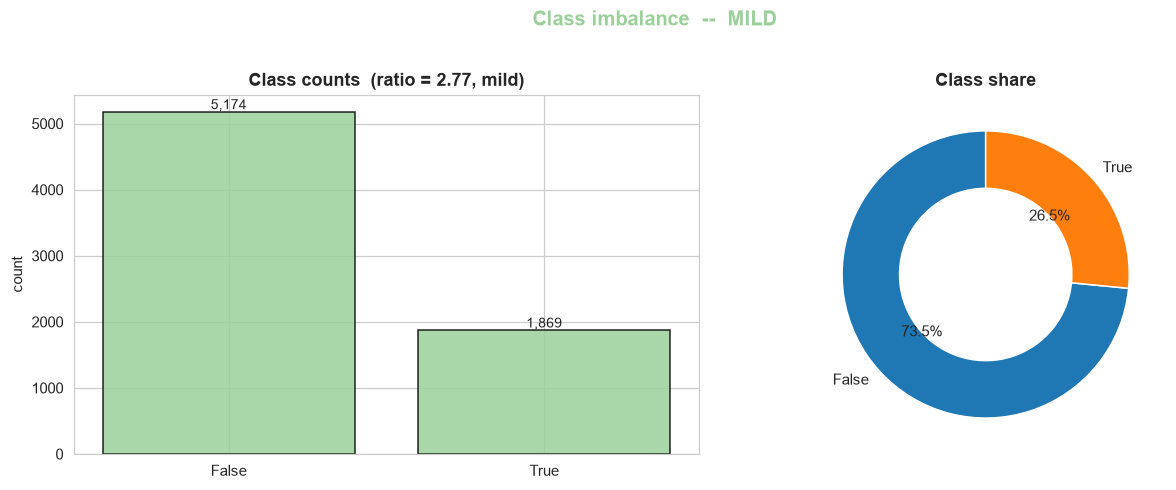

In [6]:
dx.class_imbalance(data["Churn"])

## Layer 1 -- the subtle crime (and why nobody gets caught)

The single most common pipeline on the internet:

> impute -> encode -> scale **on the whole table**, then `train_test_split`,
> then fit the model.

Every one of those three steps is stateful. Fitting them on all rows means the
test rows' medians, category vocabularies and scaling statistics contaminate
what the model trains on. dextra's own docstring calls `handle_missing` /
`clip_outliers` "**leakage-prone** cleaning steps" -- the library literally
labels the hazard.

The honest question is not whether this is wrong (it is). It is **how much it
costs on a dataset like Telco**. Let's measure instead of moralize.

In [7]:
CAT = ["gender", "MultipleLines", "InternetService", "OnlineSecurity",
       "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
       "StreamingMovies", "Contract", "PaymentMethod"]
NUM = ["tenure", "MonthlyCharges", "TotalCharges"]

TELCO_STEPS = [
    {"fn": "handle_missing", "strategy": {"TotalCharges": "median"}},   # stateful: learns a median
    {"fn": "encode", "cols": CAT, "method": "onehot", "inplace": True}, # stateful: learns vocabularies
    {"fn": "scale", "cols": NUM, "method": "standard", "inplace": True},# stateful: learns mean/std
]

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def test_auc(train_fe, test_fe, target="Churn"):
    """One fixed measuring device for every Telco protocol below."""
    X_tr = train_fe.drop(columns=[target])
    X_te = test_fe.drop(columns=[target]).reindex(columns=X_tr.columns, fill_value=0)
    model = LogisticRegression(max_iter=2000).fit(X_tr, train_fe[target].astype(int))
    return roc_auc_score(test_fe[target].astype(int), model.predict_proba(X_te)[:, 1])

train_idx, test_idx = train_test_split(
    data.index, test_size=0.25, random_state=42, stratify=data["Churn"])
print(f"train {len(train_idx):,} rows | test {len(test_idx):,} rows")

train 5,282 rows | test 1,761 rows


In [9]:
# WRONG -- fit the preprocessing on ALL rows, split afterwards
fe_all = dx.featpipe(data, steps=TELCO_STEPS, show=False, plot=False)
auc_wrong = test_auc(fe_all.loc[train_idx], fe_all.loc[test_idx])
print(f"leaky protocol   test AUC = {auc_wrong:.4f}")

leaky protocol   test AUC = 0.8465


Feature pipeline for: DataFrame  (3 step(s), mode=fit)
------------------------------------------------------


,fn,method,cols_before,cols_after,cols_added,touched
step,,,,,,
0,handle_missing,-,20,20,0,TotalCharges
1,encode,onehot,20,42,33,-
2,scale,standard,42,42,0,"tenure, MonthlyCharges, TotalCharges"



Decision: Fitted a 3-step featpipe pipeline (handle_missing -> encode -> scale); 33 new column(s) produced; combined params is a versioned, JSON-serialisable artifact. Apply to held-out data with featpipe(df_test, params=...).



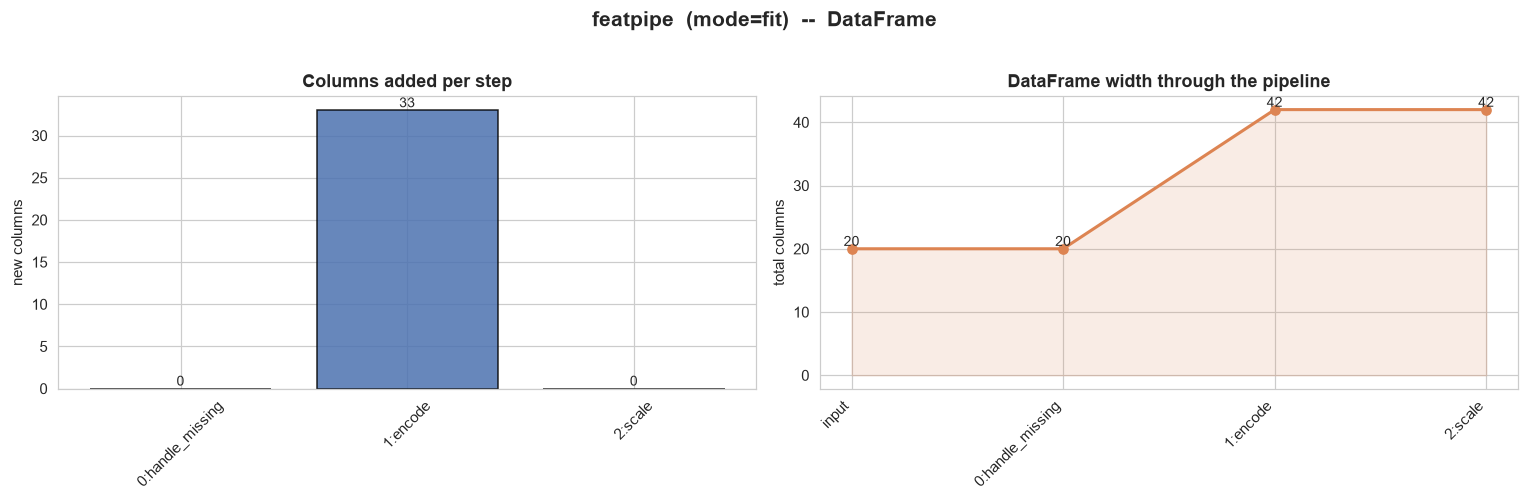


clean protocol   test AUC = 0.8465


In [10]:
# RIGHT -- split first; FIT on train only; APPLY the frozen params to test.
# FIT mode prints its full report: watch it disclose every fitted statistic.
train_fe, telco_params = dx.featpipe(
    data.loc[train_idx], steps=TELCO_STEPS, return_params=True)
test_fe = dx.featpipe(data.loc[test_idx], params=telco_params, show=False, plot=False)
auc_right = test_auc(train_fe, test_fe)
print(f"\nclean protocol   test AUC = {auc_right:.4f}")

In [11]:
# The artifact IS the isolation: the train-only median is frozen inside it,
# and APPLY replayed it on test -- no re-fitting, ever.
import json

def contains_value(obj, target, rel=1e-9):
    if isinstance(obj, dict):
        return any(contains_value(v, target, rel) for v in obj.values())
    if isinstance(obj, list):
        return any(contains_value(v, target, rel) for v in obj)
    return (isinstance(obj, (int, float)) and not isinstance(obj, bool)
            and abs(obj - target) <= rel * max(1.0, abs(target)))

train_median = data.loc[train_idx, "TotalCharges"].median()
step0 = telco_params["steps"][0]                      # the handle_missing step
print("train-only TotalCharges median :", train_median)
print("frozen inside the artifact     :", contains_value(step0, train_median))
print("\nstep summary:", telco_params["metadata"]["step_summary"])
print("\nhandle_missing params (excerpt):")
print(json.dumps(step0, default=str)[:400], "...")

train-only TotalCharges median : 1387.4
frozen inside the artifact     : True

step summary: [{'step': 0, 'fn': 'handle_missing', 'method': None, 'cols_touched': ['TotalCharges'], 'cols_added': [], 'cols_removed': []}, {'step': 1, 'fn': 'encode', 'method': 'onehot', 'cols_touched': [], 'cols_added': ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'St

In [12]:
print(f"leaky protocol : {auc_wrong:.4f}")
print(f"clean protocol : {auc_right:.4f}")
print(f"difference     : {auc_wrong - auc_right:+.4f}")

leaky protocol : 0.8465
clean protocol : 0.8465
difference     : +0.0000


### The honest reading

**0.8465 vs 0.8465 -- identical to the fourth decimal place.** On a dataset
like Telco -- 7,043 rows, 40-odd engineered features, medians and means that
barely move between random subsets -- the subtle crime leaves **no
fingerprints at all**.

This is precisely why people keep committing it: they "checked" once on tame
data, saw no difference, and concluded that split order is pedantry. Hold that
thought. The next section is what that conclusion costs when the data stops
being tame.

## Part 2 -- KDD Cup 09: where the crime turns catastrophic

Orange's churn data is the opposite regime: 230 anonymized columns, most of
them mostly empty, and a rare positive class. From its 50,000 rows we take a
**small, documented sample -- 800 rows, stratified, fixed seed** -- because
that is the honest recreation of the setting where selection leakage
detonates: **many candidate features, few labeled rows**. Think biomarker
panels, credit pilots, churn models for a young product. With all 50,000 rows
the selection statistics stabilize and the trap softens; at n=800 the bias
becomes material. We are not cherry-picking a weakness -- we are reproducing the regime
the trap was named for, and every choice (sample size, seed) is printed and
replayable.

In [13]:
from sklearn.datasets import fetch_openml

# First call downloads once from OpenML into data/openml/, then it is cached.
kdd_raw = fetch_openml(data_id=1112, as_frame=True, data_home=str(DATA_DIR / "openml"))
kdd = kdd_raw.frame
kdd["CHURN"] = pd.to_numeric(kdd["CHURN"].astype(str))   # -> {-1, 1} whatever the source dtype
num_cols = [c for c in kdd.columns if c != "CHURN" and kdd[c].dtype.kind in "if"]
print(f"full table: {kdd.shape[0]:,} x {kdd.shape[1]} | numeric feature columns: {len(num_cols)}")

full table: 50,000 x 231 | numeric feature columns: 192


In [14]:
SAMPLE_SEED = 0
Xy = kdd[num_cols + ["CHURN"]]
sample, _ = train_test_split(
    Xy, train_size=800, stratify=Xy["CHURN"], random_state=SAMPLE_SEED)
print(f"sample: {sample.shape[0]} x {sample.shape[1]} | "
      f"churners: {(sample.CHURN == 1).sum()} ({(sample.CHURN == 1).mean():.1%})")

sample: 800 x 193 | churners: 59 (7.4%)


In [15]:
miss = sample[num_cols].isna().mean()
print(f"numeric columns  >60% missing : {(miss > 0.60).sum():3d} / {len(num_cols)}")
print(f"numeric columns 100% missing  : {(miss == 1.0).sum():3d}")
print(f"numeric columns fully observed: {(miss == 0.0).sum():3d}")
print(f"candidate pool (<=97% missing): {(miss <= 0.97).sum():3d}")

numeric columns  >60% missing : 150 / 192
numeric columns 100% missing  :  18
numeric columns fully observed:   3
candidate pool (<=97% missing):  95


### The prep recipe (and a trap worth naming)

Two chained `handle_missing` steps: first **drop** only the truly hopeless
columns (more than 97% empty -- including 18 that are 100% empty), then
**impute** every survivor with medians. Both steps are stateful; both live
inside one `featpipe` artifact, so APPLY replays the exact drop list and the
exact train medians on any other rows.

Why such a permissive threshold? **Selection leakage needs candidates to
choose from.** This dataset's missingness is bimodal -- columns are either
mostly observed or almost entirely empty -- so a conventional 60% threshold
leaves just 42 survivors, and "selecting" 40 out of 42 is no selection at all
(we measured it: the two protocols land within a hair of each other). Casting
the net to 97% gives the ANOVA step 95 candidates competing for 40 seats --
the wide-net, weak-signal regime where this crime actually gets committed.

One deliberate omission: **no `scale` step here.** `CHURN` is numeric (-1/1),
and `scale` with its default `cols=None` would happily standardize *the
target* along with every other numeric column -- a trap for any dataset with
a numeric label. Instead, our measuring model carries its own scaler inside
(`StandardScaler -> LogisticRegression`), which is leak-safe by construction
-- the scaler is re-fitted on whatever that model trains on -- and identical
across every protocol we compare. On unscaled features spanning wildly
different magnitudes, logistic regression needs it.

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

KDD_PREP = [
    {"fn": "handle_missing", "strategy": "drop_cols", "drop_threshold": 0.97},
    {"fn": "handle_missing", "strategy": "median"},
]
KDD_SELECT = [{"fn": "relevance", "method": "anova", "keep": 40}]

def kdd_auc(train_sel, test_sel, target="CHURN"):
    """One fixed measuring device for every KDD protocol below."""
    feats = [c for c in train_sel.columns if c != target]
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    model.fit(train_sel[feats], (train_sel[target] == 1).astype(int))
    return roc_auc_score((test_sel[target] == 1).astype(int),
                         model.predict_proba(test_sel[feats])[:, 1])

kdd_train_idx, kdd_test_idx = train_test_split(
    sample.index, test_size=0.25, random_state=42, stratify=sample["CHURN"])
print(f"train {len(kdd_train_idx)} rows | test {len(kdd_test_idx)} rows")

train 600 rows | test 200 rows


## Layer 2 -- the catastrophic crime

The wrong way, as seen in the wild: score all the features against the target
**using every row you own**, keep the best 40, *then* split and evaluate. The
selection step saw the test labels; the 40 survivors are partly noise that
happens to correlate with those specific test rows.

Below: what one ordinary train/test check says about that crime. Read the two
numbers before believing anything.

Feature-selection pipeline for: fe_all_kdd  (1 step(s), mode=fit)
-----------------------------------------------------------------


,fn,method,cols_before,cols_after,cols_dropped
step,,,,,
0,relevance,anova,96,41,55



Decision: Fitted a 1-step selectpipe pipeline (relevance); dropped 55 column(s), 41 remain; combined params is a versioned, JSON-serialisable artifact. Apply to held-out data with selectpipe(df_test, params=...).



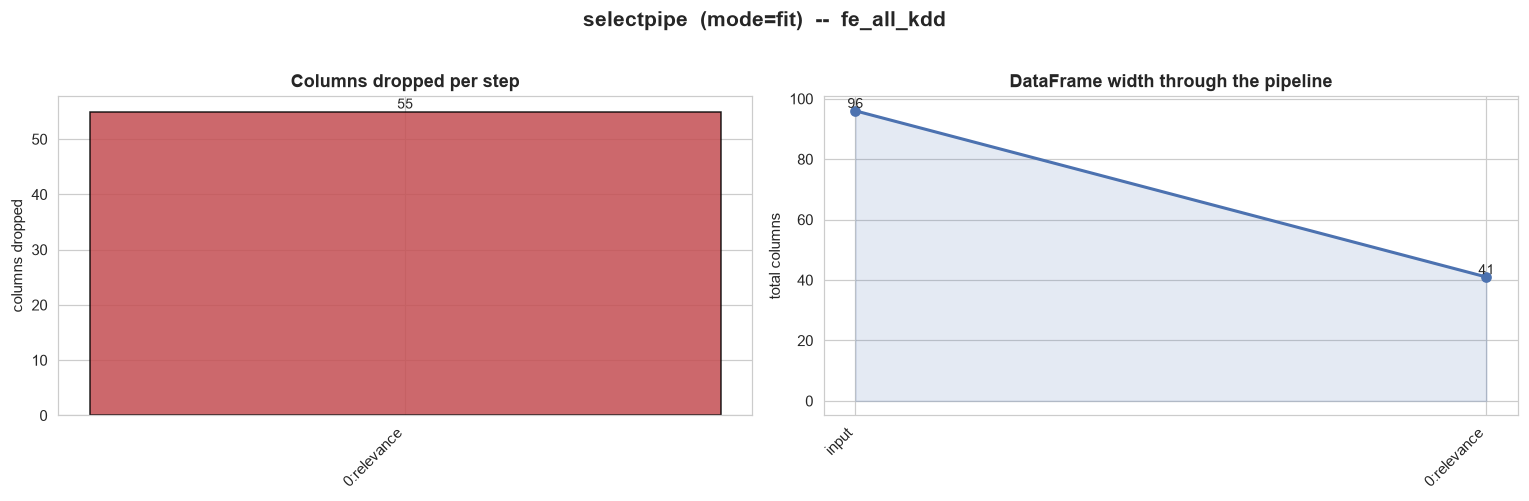


leaky protocol   test AUC = 0.5240


In [17]:
# WRONG -- impute + select on ALL 800 rows, split afterwards.
# The selection FIT report prints: watch it score features on every row.
fe_all_kdd = dx.featpipe(sample, steps=KDD_PREP, show=False, plot=False)
sel_all = dx.selectpipe(fe_all_kdd, steps=KDD_SELECT, y="CHURN")
auc_kdd_wrong = kdd_auc(sel_all.loc[kdd_train_idx], sel_all.loc[kdd_test_idx])
print(f"\nleaky protocol   test AUC = {auc_kdd_wrong:.4f}")

Feature-selection pipeline for: kdd_test_fe  (1 step(s), mode=apply)
--------------------------------------------------------------------


,fn,method,cols_before,cols_after,cols_dropped
step,,,,,
0,relevance,anova,69,41,28



Decision: Applied a saved 1-step selectpipe pipeline (relevance; fitted 2026-07-04T18:24:37Z); dropped 28 column(s), 41 remain; no re-scoring -- leakage-safe.



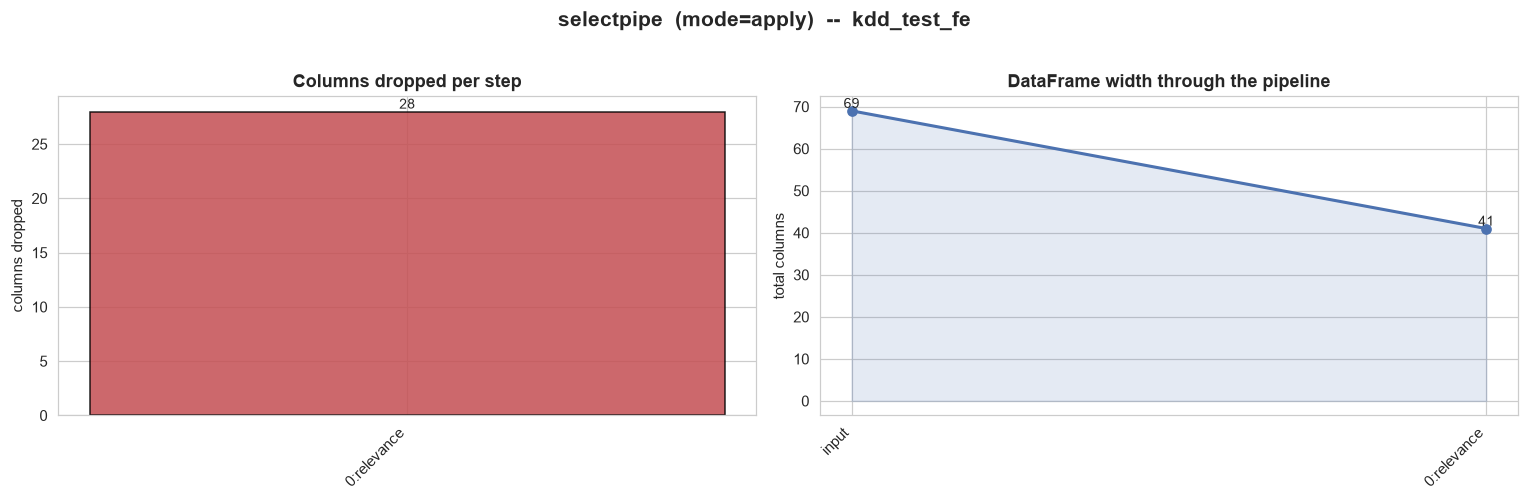


clean protocol   test AUC = 0.5315


In [18]:
# RIGHT -- split; FIT prep + selection on train only; APPLY both to test.
kdd_train_fe, kdd_prep_params = dx.featpipe(
    sample.loc[kdd_train_idx], steps=KDD_PREP, return_params=True,
    show=False, plot=False)
kdd_test_fe = dx.featpipe(
    sample.loc[kdd_test_idx], params=kdd_prep_params, show=False, plot=False)

kdd_train_sel, kdd_sel_params = dx.selectpipe(
    kdd_train_fe, steps=KDD_SELECT, y="CHURN", return_params=True,
    show=False, plot=False)
# APPLY mode: subsets to the fitted columns only -- no re-scoring on test.
kdd_test_sel = dx.selectpipe(kdd_test_fe, params=kdd_sel_params)

auc_kdd_right = kdd_auc(kdd_train_sel, kdd_test_sel)
print(f"\nclean protocol   test AUC = {auc_kdd_right:.4f}")

In [19]:
picked_leaky = {c for c in sel_all.columns if c != "CHURN"}
picked_clean = {c for c in kdd_train_sel.columns if c != "CHURN"}

print(f"leaky protocol : {auc_kdd_wrong:.4f}")
print(f"clean protocol : {auc_kdd_right:.4f}")
print(f"inflation      : {auc_kdd_wrong - auc_kdd_right:+.4f}")
print(f"feature overlap between the two protocols: "
      f"{len(picked_leaky & picked_clean)} / {len(picked_clean)}")

leaky protocol : 0.5240
clean protocol : 0.5315
inflation      : -0.0076
feature overlap between the two protocols: 26 / 40


### What just happened -- read it twice

**The crime did not show up.** This split reports the leaky protocol at
0.5240 and the clean one at 0.5315: the cheat *lost*, by 0.0076. Meanwhile the
overlap line says the two protocols genuinely disagree about which 40 columns
matter (26 in common out of 40) -- the contamination is real, the selected
sets differ, and yet the single measurement acquits it.

This is the uncomfortable lesson of the layer: on weak-signal data, one
train/test split is a noisy instrument -- its randomness is larger than the
bias you are trying to detect. Audit leakage with a single split and you will
acquit the guilty routinely, and occasionally convict the innocent.

So how do you ever *see* a bias buried in noise? The same way physics does:
repeat the measurement.

## Layer 3 -- repeat until the truth surfaces

Was seed 42 unlucky, or is the crime actually free? Neither answer can come
from one draw. We rerun the whole experiment on **20 fresh random splits**:
both protocols on each split, identical measuring device throughout.

In [20]:
def protocol_auc(seed, leaky):
    """One full run of either protocol on a fresh random split."""
    tr_i, te_i = train_test_split(sample.index, test_size=0.25,
                                  random_state=seed, stratify=sample["CHURN"])
    if leaky:   # fit everything on ALL rows, then split
        fe  = dx.featpipe(sample, steps=KDD_PREP, show=False, plot=False)
        sel = dx.selectpipe(fe, steps=KDD_SELECT, y="CHURN", show=False, plot=False)
        tr, te = sel.loc[tr_i], sel.loc[te_i]
    else:       # fit on train only, APPLY to test
        tr, p = dx.featpipe(sample.loc[tr_i], steps=KDD_PREP,
                            return_params=True, show=False, plot=False)
        te = dx.featpipe(sample.loc[te_i], params=p, show=False, plot=False)
        tr, s = dx.selectpipe(tr, steps=KDD_SELECT, y="CHURN",
                              return_params=True, show=False, plot=False)
        te = dx.selectpipe(te, params=s, show=False, plot=False)
    return kdd_auc(tr, te)

In [21]:
SEEDS = range(20)
results = pd.DataFrame({
    "leaky": [protocol_auc(s, leaky=True)  for s in SEEDS],
    "clean": [protocol_auc(s, leaky=False) for s in SEEDS],
}, index=pd.Index(SEEDS, name="seed"))
results.describe().loc[["mean", "std", "min", "max"]].round(4)

,leaky,clean
mean,0.6857,0.6564
std,0.0797,0.0799
min,0.4915,0.5110
max,0.8159,0.7838


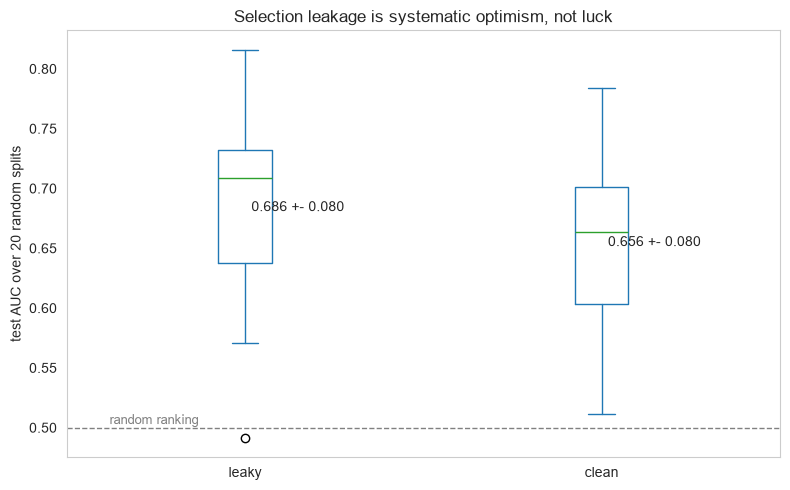

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
results.plot.box(ax=ax, grid=False)
for i, col in enumerate(results.columns, start=1):
    m, s = results[col].mean(), results[col].std()
    ax.annotate(f"{m:.3f} +- {s:.3f}", (i, m), textcoords="offset points",
                xytext=(38, -4), ha="center", fontsize=10)
ax.axhline(0.5, ls="--", lw=1, color="grey")
ax.annotate("random ranking", (0.62, 0.503), fontsize=9, color="grey")
ax.set_ylabel("test AUC over 20 random splits")
ax.set_title("Selection leakage is systematic optimism, not luck")
plt.tight_layout()
plt.show()

### Read the two boxes

Now the pattern surfaces: **leaky 0.6857 +- 0.0797 vs clean 0.6564 +- 0.0799**
-- a systematic **+0.029** shift, bought entirely by letting the selection
step peek at the evaluation rows.

But look at the widths: the split-to-split noise (+-0.08) is nearly three
times the bias. That is exactly why Layer 2's single split saw nothing -- and
it points at the endgame: to expose a bias, you must shrink the noise.
Averaging does that. Repeating does that. The next section does both.

### The endgame: repeated cross-validation, with and without the crime

Cross-validation already averages five folds, so a CV mean is a far less
noisy instrument than one split. Repeat it ten times with different shuffles
and the noise shrinks further. Which sets up the law this notebook exists to
state: **averaging shrinks variance; it never touches bias.** If selection
leaked, every fold of every repeat inherits the same contamination.

dextra ships sklearn-legitimate wrappers for exactly this --
`DextraFeaturePipeline` / `DextraSelectPipeline` are transformers whose `fit`
runs FIT mode and whose `transform` runs APPLY mode -- so putting the *entire*
pipeline inside every fold costs one import. The comparison below runs both
worlds ten times each:

- **leaky CV**: prep + selection fitted once on all 800 rows (Layer 2's
  `sel_all`), only the classifier is cross-validated -- the classic "wrong
  way to do cross-validation" from the textbooks;
- **honest CV**: prep + selection re-fitted inside every fold, via compat.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from dextra.compat import DextraFeaturePipeline, DextraSelectPipeline

y01 = (sample["CHURN"] == 1).astype(int)
leaky_feats = [c for c in sel_all.columns if c != "CHURN"]

honest_pipe = Pipeline([
    ("prep",   DextraFeaturePipeline(steps=KDD_PREP)),
    ("select", DextraSelectPipeline(steps=KDD_SELECT)),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000)),
])
clf_only = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

cv_runs = []
for seed in range(10):
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    leaky_cv  = cross_val_score(clf_only, sel_all[leaky_feats], y01,
                                cv=cv, scoring="roc_auc").mean()
    honest_cv = cross_val_score(honest_pipe, sample[num_cols], y01,
                                cv=cv, scoring="roc_auc").mean()
    cv_runs.append({"seed": seed, "leaky_cv": leaky_cv,
                    "honest_cv": honest_cv, "gap": leaky_cv - honest_cv})
cv_res = pd.DataFrame(cv_runs).set_index("seed")
print(cv_res.round(4).to_string())
print(f"\nmean bias: {cv_res.gap.mean():+.4f} +- {cv_res.gap.std():.4f}"
      f"  |  leaky ahead in {(cv_res.gap > 0).sum()} of {len(cv_res)} repeats")

      leaky_cv  honest_cv     gap
seed                             
0       0.7068     0.6692  0.0376
1       0.6987     0.6583  0.0404
2       0.6882     0.6507  0.0375
3       0.6221     0.5916  0.0306
4       0.6812     0.6388  0.0424
5       0.6690     0.6583  0.0107
6       0.6575     0.6651 -0.0076
7       0.6616     0.6578  0.0037
8       0.6386     0.6307  0.0079
9       0.7000     0.6418  0.0582

mean bias: +0.0261 +- 0.0210  |  leaky ahead in 9 of 10 repeats


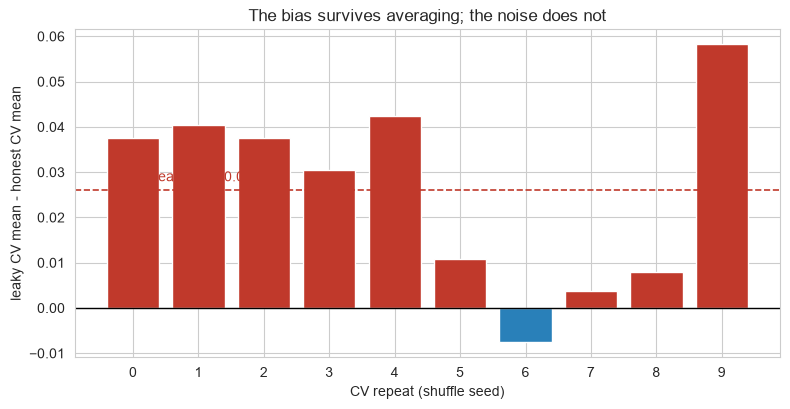

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#c0392b" if g > 0 else "#2980b9" for g in cv_res["gap"]]
ax.bar(cv_res.index, cv_res["gap"], color=colors)
ax.axhline(0, lw=1, color="black")
ax.axhline(cv_res["gap"].mean(), ls="--", lw=1.2, color="#c0392b")
ax.annotate(f"mean bias {cv_res['gap'].mean():+.4f}",
            (0.2, cv_res["gap"].mean()), textcoords="offset points",
            xytext=(0, 6), fontsize=10, color="#c0392b")
ax.set_xlabel("CV repeat (shuffle seed)")
ax.set_xticks(list(cv_res.index))
ax.set_ylabel("leaky CV mean - honest CV mean")
ax.set_title("The bias survives averaging; the noise does not")
plt.tight_layout()
plt.show()

### The verdict

Ten repeats: the leaky estimate beats the honest one in **9 of 10**, mean bias
**+0.026**, while the repeat-to-repeat noise of a CV mean has fallen to about
+-0.02. Compare the ladder you just climbed: a single split hid a +0.03 bias
inside +-0.08 of noise; twenty splits exposed its direction; repeated CV
melted the noise down until the bias stood alone.

And the one blue bar is the final warning: even a full 5-fold CV can
occasionally acquit the crime. Nothing you compute *after* the leak will
catch it reliably.

**You do not detect leakage; you design it out.**

The honest column is the number you are allowed to publish: about **0.646 on
average** -- consistent with the clean protocol's world from the boxplot, not
with the leaky one. The habit to take home: whatever fits, goes inside the
fold. `dextra.compat` makes that cost exactly one import.

## The honest finale -- evaluating the model we actually trust (Telco)

Back to Telco with everything learned. We reuse Layer 1's clean split and its
FIT/APPLY features: `classify` cross-validates a forest baseline **on train
only** and hands back a hybrid artifact; every diagnostic below is then judged
on the untouched test rows in *artifact mode* -- the truth column, the fitted
estimator and the feature list all travel inside the artifact.

Classification baseline for: train_fe  (method=forest, target=Churn, mode=fit)
------------------------------------------------------------------------------


,train,cv
ACCURACY,0.9979,0.7938
F1,0.9979,0.7843
ROC_AUC,0.9999,0.8231



Decision: 'forest' classification baseline (binary) -- CV accuracy=0.7938, F1=0.7843, ROC-AUC=0.8231 (5-fold, stratified). Train accuracy=0.9979. Predicted labels added as 'Churn_pred'. Persist with joblib.dump(params['estimator'], ...).



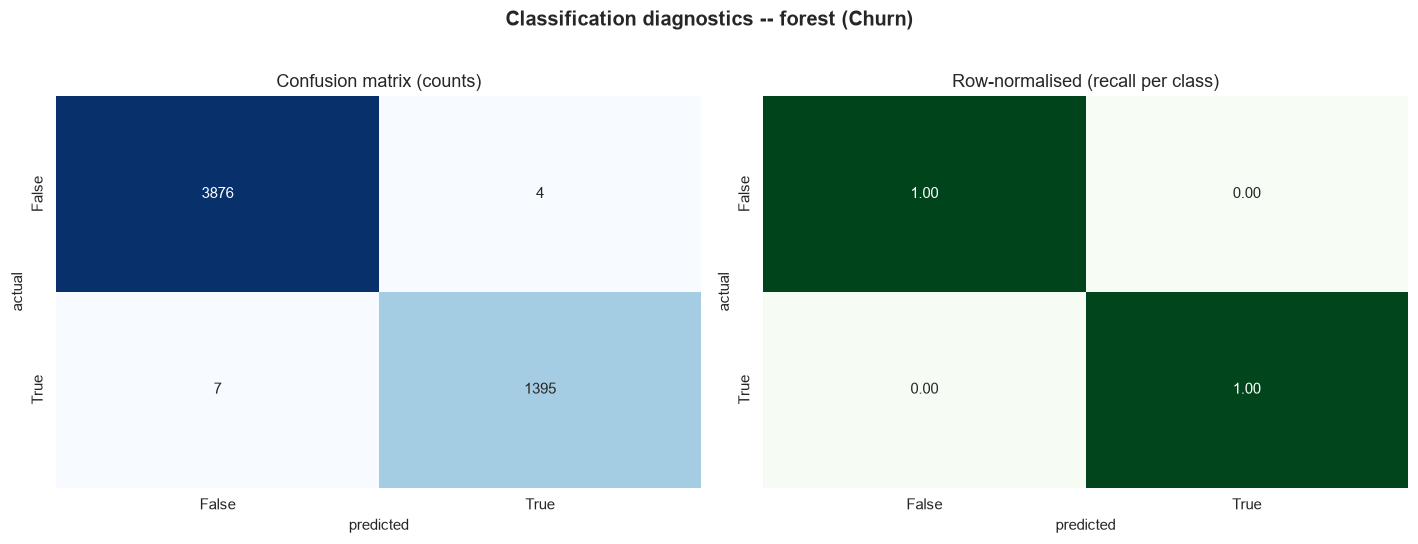

In [25]:
churn_train, clf_params = dx.classify(
    train_fe, y="Churn", method="forest", cv=5, return_params=True)

Read the card before celebrating: cross-validated ROC-AUC **0.8231** against
a train accuracy of **0.9979** -- the forest memorizes its training rows
almost perfectly, and only the cross-validated row is telling the truth. We
will quantify that distance properly with learning curves below.

Confusion report for: test_fe  (target=Churn, mode=artifact)
------------------------------------------------------------


,precision,recall,f1,support
False,0.8276,0.8980,0.8614,"1,294"
True,0.6303,0.4818,0.5461,467
accuracy,-,-,0.7876,"1,761"
macro avg,0.7289,0.6899,0.7037,"1,761"
weighted avg,0.7753,0.7876,0.7778,"1,761"



Decision: 1761 rows, 2 classes: accuracy=0.7876, weighted-F1=0.7778, macro-F1=0.7037. Weakest class 'True' recall=0.4818 (mode=artifact).



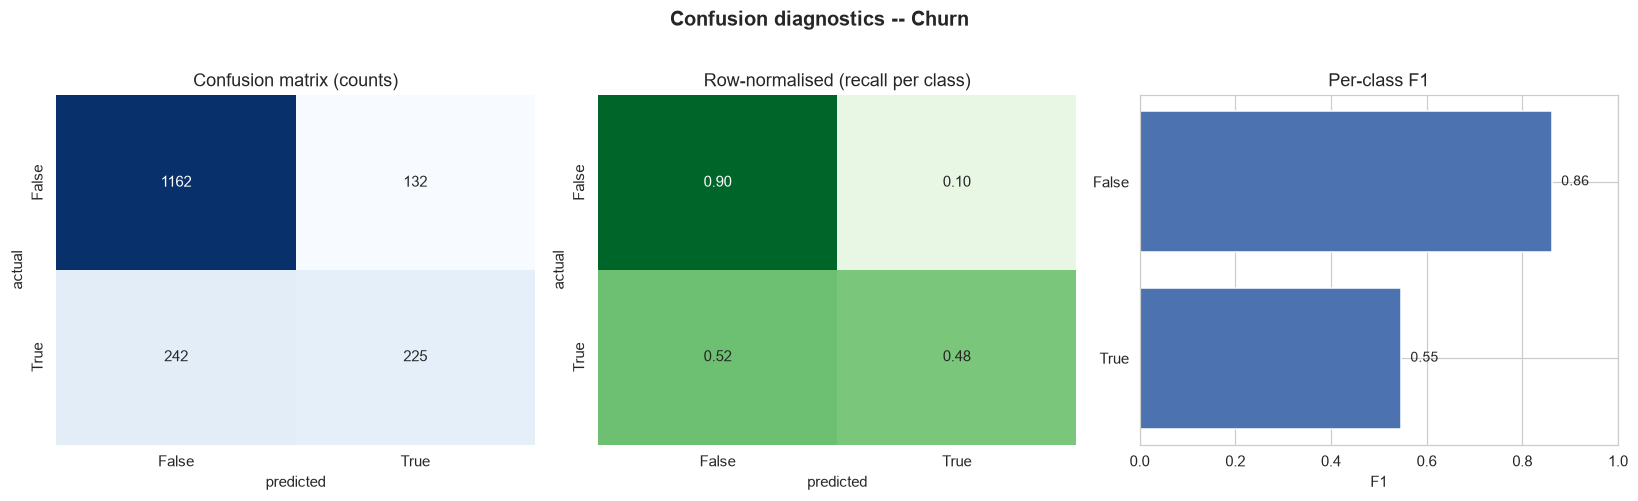

In [26]:
report = dx.confusion_report(test_fe, params=clf_params)

ROC / PR report for: test_fe  (target=Churn, mode=artifact)
-----------------------------------------------------------


,roc_auc,avg_precision
positive (True),0.8225,0.6116



Decision: Binary ranking: macro ROC-AUC=0.8225, macro avg-precision=0.6116 over 2 class(es) (mode=artifact). ROC-AUC 0.5 = random; pick a threshold from the PR curve to fit your precision/recall trade-off.



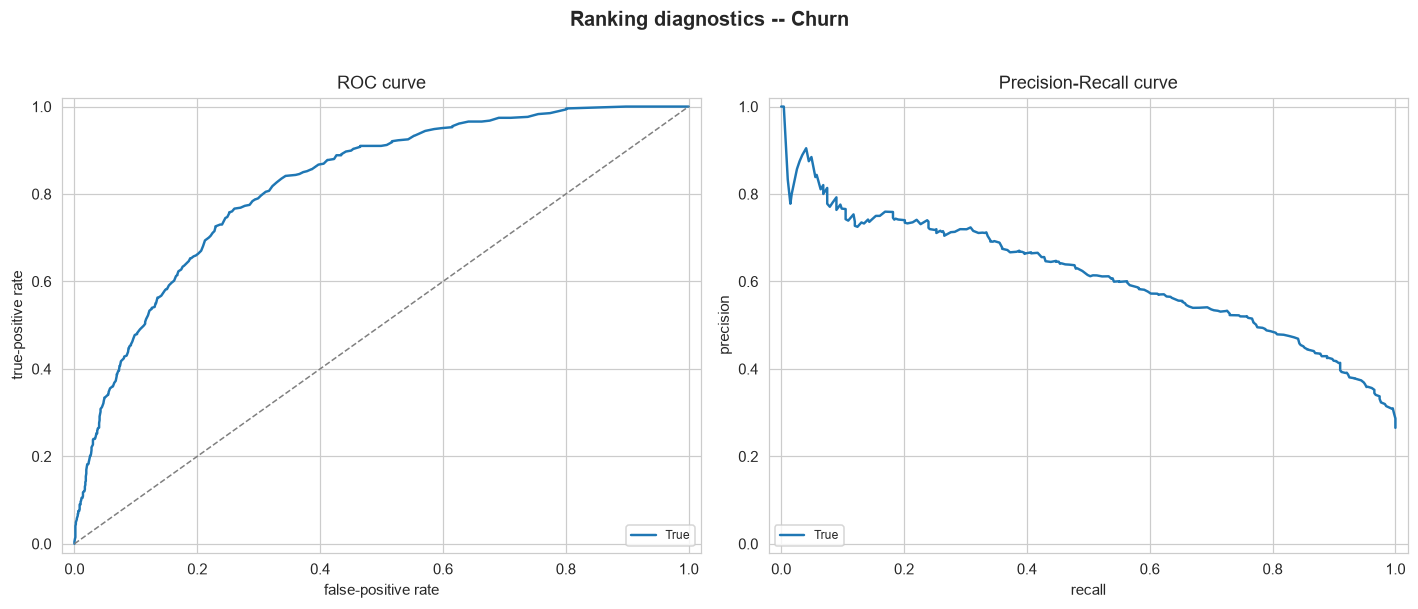

In [27]:
curves = dx.roc_pr(test_fe, params=clf_params)

### Reading the test-set diagnostics

Three things to notice, all computed on rows no fitted step ever saw:

- **The confusion report exposes what accuracy hides.** Test accuracy reads a
  comfortable **0.7876** -- while recall on the churner class, the class the
  business actually cares about, is **0.4818**: we miss every second churner.
  The per-class table makes that impossible to gloss over.
- **ROC-AUC summarizes ranking, the PR curve prices it.** Test ROC-AUC is
  **0.8225**; with a 26.5% churn base rate, the average precision of
  **0.6116** is the number to negotiate thresholds with -- it tells you what
  precision you can afford at the recall you need.
- **These are the same functions the leaky pipelines would have flattered.**
  Everything in this suite is only as honest as the isolation upstream of it.

Learning curves for: train_fe  (target=Churn, scoring=accuracy, mode=artifact)
------------------------------------------------------------------------------


,train_mean,train_std,cv_mean,cv_std
train_size,,,,
422,1.0000,0.0000,0.7783,0.0192
1373,0.9996,0.0004,0.7838,0.0114
2323,0.9993,0.0006,0.7891,0.0109
3274,0.9989,0.0004,0.7876,0.0147
4225,0.9982,0.0005,0.7859,0.0136



Decision: learning curve (accuracy, 5-fold): final train=0.9982, CV=0.7859, gap=0.2123. Diagnosis: high variance (overfitting): the train-CV gap is wide -- add data or regularise (mode=artifact).



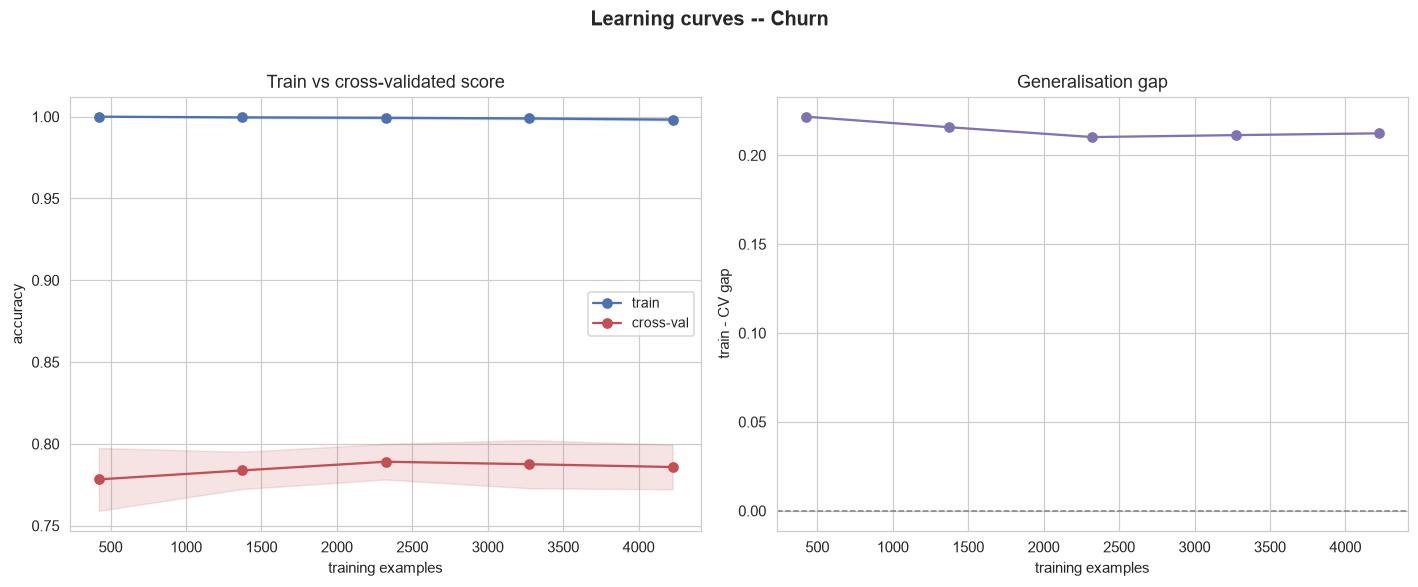

In [28]:
lc = dx.learning_curves(train_fe, params=clf_params)

The learning-curve card names the regime for you: final train accuracy
**0.9982** against cross-validated **0.7859** -- a **0.2123** gap that stays
wide at every training size. That is the signature of **high variance**: the
model memorizes faster than it generalizes. The honest menu at that point --
more data, stronger regularization, or a lighter model. And because every
step upstream was leak-free, you can trust that this diagnosis describes the
model, not an artifact of contaminated preprocessing.

## The Five Commandments of Isolation

1. **Split before anything learns.** The test set exists from the moment the
   project starts; nothing fitted may see it.
2. **FIT on train, APPLY everywhere else.** A params artifact is a contract:
   frozen statistics, replayed verbatim. `featpipe` / `selectpipe` make the
   contract explicit, inspectable and JSON-serializable.
3. **Feature selection is a fitted step -- the most treacherous one.** Wide
   data + few rows + selection-before-split injects a bias no single check
   will ever show you.
4. **Know stateless from stateful.** Casting types and dropping IDs can
   happen anywhere; medians, vocabularies, scaler statistics and feature
   scores cannot.
5. **In cross-validation, the whole pipeline lives inside the fold.**
   `dextra.compat` exists so that this costs exactly one import.

**Decision:** on Telco the subtle crime was free to four decimal places; on
KDD Cup 09 the selection crime injected roughly **+0.03 of systematic
fiction** -- small enough to hide inside any single check, large enough to
misrank models and mislead a launch decision. Same crime, different data --
which is why the *protocol* is the rule, not the outcome. You never know in
advance which dataset you are holding.

## Recap

- **Layer 1 (Telco):** impute/encode/scale before the split moved test AUC by
  exactly nothing -- 0.8465 vs 0.8465. Subtle crimes leave no fingerprints on
  tame data, which is how they survive code review.
- **Layer 2 (KDD Cup 09, n=800, 95 candidates):** one split *acquitted* the
  selection crime (-0.0076) even though the two protocols disagreed on 14 of
  their 40 picked features -- a single check is noise, not an audit.
- **Layer 3 (20 splits, then 10x repeated CV):** the truth surfaces -- +0.029
  mean bias across splits, +0.026 across repeated CV, leaky ahead in 9 of 10
  repeats. Averaging killed the noise; it could not touch the bias.
- **Finale (Telco, leak-free end to end):** cross-validated forest at ROC-AUC
  0.8231, judged on untouched test rows: AUC 0.8225, average precision 0.6116,
  churner recall 0.4818, learning-curve gap 0.2123 -> high-variance diagnosis.

**Links:** [dextra documentation](https://ahmedabdeltawab602-collab.github.io/dextra/) |
[GitHub repository](https://github.com/ahmedabdeltawab602-collab/dextra) |
[PyPI: pydextra](https://pypi.org/project/pydextra/) |
Notebook 1: *From a Messy CSV to an Actionable Data Report in 10 Minutes*

**Next in the series:** notebook 3 takes dextra into a full Arabic-language
analysis of a real regional dataset -- same honesty, different alphabet.